In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)


models = {
    'Naive Bayes': Pipeline([
        ("clf", MultinomialNB())   # Best NB model for word-frequency data
    ]),

    'Logistic Regression': Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=5000,
            solver="lbfgs",
            n_jobs=-1
        ))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=None
    ),

    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=300
    )
}


## 1. Load the Spambase data

In [8]:

# Adjust the path if necessary
df = pd.read_csv("spambase.csv", header=None)
print("Shape:", df.shape)
df.head()


Shape: (4601, 58)


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## 2. Assign official UCI column names

In [9]:

colnames = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d",
    "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet",
    "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will",
    "word_freq_people", "word_freq_report", "word_freq_addresses", "word_freq_free",
    "word_freq_business", "word_freq_email", "word_freq_you", "word_freq_credit",
    "word_freq_your", "word_freq_font", "word_freq_000", "word_freq_money",
    "word_freq_hp", "word_freq_hpl", "word_freq_george", "word_freq_650",
    "word_freq_lab", "word_freq_labs", "word_freq_telnet", "word_freq_857",
    "word_freq_data", "word_freq_415", "word_freq_85", "word_freq_technology",
    "word_freq_1999", "word_freq_parts", "word_freq_pm", "word_freq_direct",
    "word_freq_cs", "word_freq_meeting", "word_freq_original", "word_freq_project",
    "word_freq_re", "word_freq_edu", "word_freq_table", "word_freq_conference",
    "char_freq_semicolon", "char_freq_left_paren", "char_freq_left_bracket",
    "char_freq_exclamation", "char_freq_dollar", "char_freq_pound",
    "capital_run_length_average", "capital_run_length_longest",
    "capital_run_length_total", "is_spam"
]

df.columns = colnames
df.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_left_paren,char_freq_left_bracket,char_freq_exclamation,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## 3. Basic exploratory data analysis

In [10]:

# Class balance
class_counts = df["is_spam"].value_counts().rename(index={0: "not_spam", 1: "spam"})
print("Class counts:\n", class_counts)
print("\nClass proportions:")
print(class_counts / class_counts.sum())

# Summary statistics of first 10 features
df.iloc[:, :10].describe().T


Class counts:
 is_spam
not_spam    2788
spam        1813
Name: count, dtype: int64

Class proportions:
is_spam
not_spam    0.605955
spam        0.394045
Name: count, dtype: float64


,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.0,0.0,0.00,4.54
word_freq_address,4601.0,0.213015,1.290575,0.0,0.0,0.0,0.00,14.28
word_freq_all,4601.0,0.280656,0.504143,0.0,0.0,0.0,0.42,5.10
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.0,0.0,0.00,42.81
word_freq_our,4601.0,0.312223,0.672513,0.0,0.0,0.0,0.38,10.00
word_freq_over,4601.0,0.095901,0.273824,0.0,0.0,0.0,0.00,5.88
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.0,0.0,0.00,7.27
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.0,0.0,0.00,11.11
word_freq_order,4601.0,0.090067,0.278616,0.0,0.0,0.0,0.00,5.26
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.0,0.0,0.16,18.18


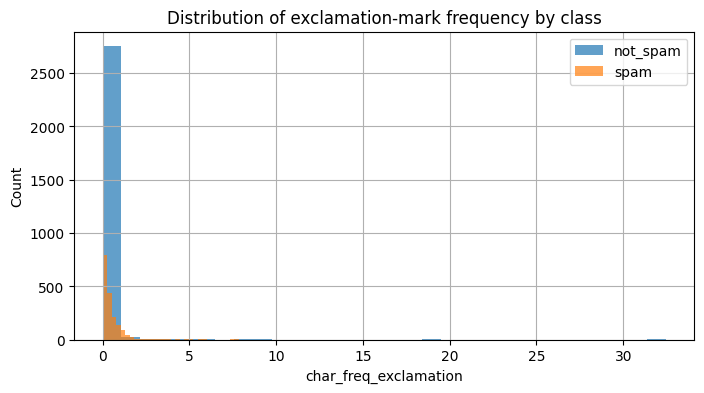

In [11]:

# Example: distribution of exclamation mark frequency by class
plt.figure(figsize=(8,4))
df[df["is_spam"] == 0]["char_freq_exclamation"].hist(bins=30, alpha=0.7, label="not_spam")
df[df["is_spam"] == 1]["char_freq_exclamation"].hist(bins=30, alpha=0.7, label="spam")
plt.xlabel("char_freq_exclamation")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of exclamation-mark frequency by class")
plt.show()


## 4. Train/test split and model definitions

In [12]:

X = df.drop(columns=["is_spam"])
y = df["is_spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True))
    ]),
    "KNN_5": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, random_state=42
    )
}


## 5. Train models and evaluate performance

In [13]:

reports = {}
roc_aucs = {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    auc = roc_auc_score(y_test, y_proba)
    print("ROC AUC:", auc)

    reports[name] = classification_report(y_test, y_pred, output_dict=True)
    roc_aucs[name] = auc

print("\nSummary of ROC AUC scores:")
for name, auc in roc_aucs.items():
    print(f"{name}: {auc:.4f}")



===== LogisticRegression =====
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       837
           1       0.92      0.89      0.91       544

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.92      1381
weighted avg       0.93      0.93      0.93      1381

ROC AUC: 0.9711812144212525

===== SVM_RBF =====
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       837
           1       0.93      0.89      0.91       544

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.92      1381
weighted avg       0.93      0.93      0.93      1381

ROC AUC: 0.9711943917351886

===== KNN_5 =====
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       837
           1       0.88      0.86      0.87       544

    accuracy                           0.90      1381


## 6. Random Forest feature importances

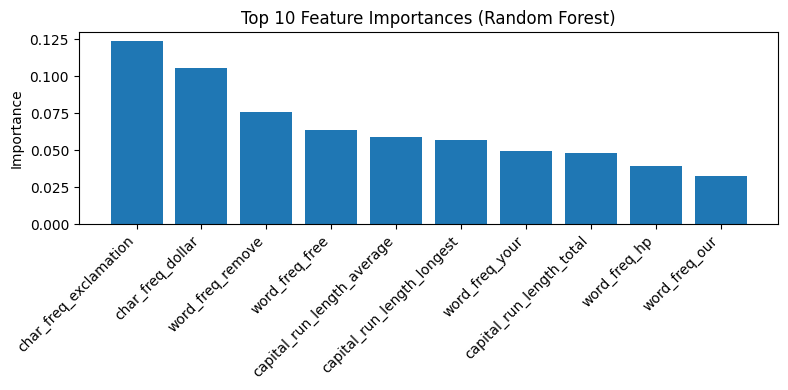

In [14]:

rf = models["RandomForest"]
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
top_features = X.columns[indices]
top_importances = importances[indices]

plt.figure(figsize=(8,4))
plt.bar(range(len(top_features)), top_importances)
plt.xticks(range(len(top_features)), top_features, rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


In [15]:

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, RocCurveDisplay


In [16]:

def hr(title=None):
    print("\n" + "="*60)
    if title is not None:
        print(title)
    print("="*60)


## 7. Simple model comparison and best-model selection

In [17]:

models = {
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc, model))
    print(f"{name:>18}: accuracy = {acc:.4f}")

results = sorted(results, key=lambda t: t[1], reverse=True)
best_name, best_acc, best_model = results[0]
hr(f"Best so far: {best_name} (accuracy {best_acc:.4f})")



       Naive Bayes: accuracy = 0.8240


C:\CODING\NMSU_CS_DEGREE\Data Mining\SPAMREPORT\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: accuracy = 0.9283
     Decision Tree: accuracy = 0.8921
     Random Forest: accuracy = 0.9558

Best so far: Random Forest (accuracy 0.9558)


## 8. Evaluate the best-performing model

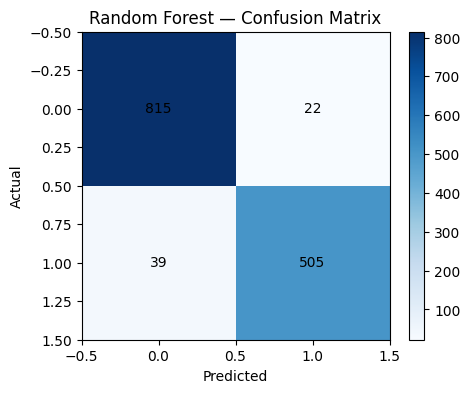

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       837
           1       0.96      0.93      0.94       544

    accuracy                           0.96      1381
   macro avg       0.96      0.95      0.95      1381
weighted avg       0.96      0.96      0.96      1381



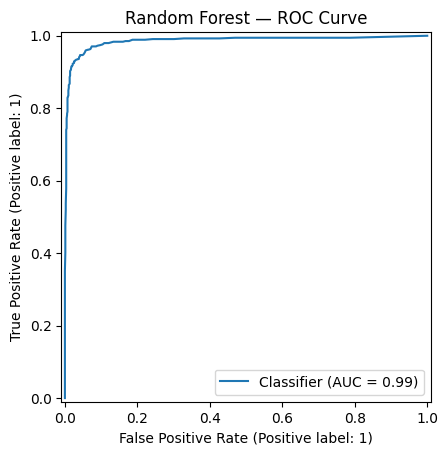

ROC AUC: 0.9859376098109496


In [18]:

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title(f"{best_name} — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for (i, j) in [(i, j) for i in range(cm.shape[0]) for j in range(cm.shape[1])]:
    plt.text(j, i, int(cm[i, j]), ha='center', va='center')
plt.colorbar()
plt.show()

print(classification_report(y_test, y_pred))

try:
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test)[:, 1]
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"{best_name} — ROC Curve")
        plt.show()
        print("ROC AUC:", roc_auc_score(y_test, y_proba))
except Exception as e:
    print("ROC not available:", e)


## 9. Save summary artifacts to disk

In [19]:

acc_df = pd.DataFrame({
    "Model": [name for name, _, _ in results],
    "Accuracy": [float(f"{acc:.4f}") for _, acc, _ in results]
})
acc_df.to_csv("accuracy_summary.csv", index=False)

cm_df = pd.DataFrame(cm, columns=["Pred 0","Pred 1"], index=["Actual 0","Actual 1"])
cm_df.to_csv("confusion_matrix_best_model.csv")

report_text = classification_report(y_test, y_pred)
with open("classification_report_best_model.txt", "w") as f:
    f.write(report_text)

hr("Saved Artifacts")
print("accuracy_summary.csv")
print("confusion_matrix_best_model.csv")
print("classification_report_best_model.txt")



Saved Artifacts
accuracy_summary.csv
confusion_matrix_best_model.csv
classification_report_best_model.txt
